# Candidate Test 2022 Analysis Part 2

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2). Consider normalizing the data or performing similar scaling transformations as needed.

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:

- An analysis/description of which questions are most crucial concerning their placement on the axes.
- Average positions of parties concerning each question, preferably with accompanying plots of each (or selected) question.
- A clustering analysis where you attempt various cluster numbers, which would correspond to different parties. Discuss whether there is room for more clusters/parties or if a reduction is needed. Make sure you cover: **K-Means, Hierarchical clustering, and DBSCAN.**
- An overview of the political landscape of the elected candidates, highlighting which members agree or disagree the most and which parties or party members have significant disagreements.
- Feel free to explore further and remember that preprocessing, methodology, and evaluation metrics are not mentioned explicitly, but are implicitly assumed.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



## Pre-Processing the data


In [5]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

from sklearn.neighbors import KernelDensity

import matplotlib as mpl
import matplotlib.gridspec as grid_spec

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.cluster import KMeans, DBSCAN
import collections
from sklearn.neighbors import NearestNeighbors
import plotly.express as px

import warnings

In [7]:
allData = pd.read_excel('alldata.xlsx')
drData = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
tv2Data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')
electedData = pd.read_excel('electeddata.xlsx')

In [11]:
allData.head()

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


In [19]:
allData.columns


Index(['530', '531', '533', '534', '535', '537', '538', '540', '541', '543',
       '544', '545', '546', '547', '548', '550', '551', '552', '553', '555',
       '556', '557', '559', '561', '563', 'navn', 'parti', '1a', '1b', '2a',
       '2b', '3a', '3b', '4a', '4b', '5a', '5b', '6a', '6b', '7a', '7b', '8a',
       '8b', '9a', '9b', '10a', '10b', '11a', '11b', '12a', '12b', 'storkreds',
       'alder'],
      dtype='object')

In [15]:
allData["parti"].unique()


array(['Moderaterne', 'Socialistisk Folkeparti', 'Alternativet',
       'Løsgænger', 'Enhedslisten', 'Danmarksdemokraterne', 'Venstre',
       'Frie Grønne, Danmarks Nye Venstrefløjsparti', 'Dansk Folkeparti',
       'Kristendemokraterne', 'Liberal Alliance', 'Nye Borgerlige',
       'Det Konservative Folkeparti', 'Radikale Venstre',
       'Socialdemokratiet'], dtype=object)

In [17]:
allData.isnull().sum().sum()

0

In [21]:
allData

,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
862,1,1,1,-2,2,-1,1,-2,1,1,...,1,2,-1,2,1,-2,0,0,Københavns Omegns Storkreds,33
863,1,-2,-2,-2,1,-2,-1,-2,-2,-2,...,-1,0,-1,2,2,-2,0,0,Københavns Omegns Storkreds,45
864,1,1,1,-2,2,-1,1,-1,-1,1,...,-1,0,-1,2,2,-2,0,1,Københavns Omegns Storkreds,52
865,1,-1,1,-2,1,-1,-1,-1,-1,1,...,0,0,0,2,1,-2,1,0,Københavns Omegns Storkreds,44


## PCA Analysis

In [26]:
scaler = StandardScaler()
pca = PCA(n_components=3)
allData_numeric = allData.select_dtypes("number")
X_pca = pca.fit_transform(allData_numeric)

In [28]:

explained_variance_ratio = pca.explained_variance_ratio_


print(f"Variance Explained by PC1: {explained_variance_ratio[0]:.2%}")
print(f"Variance Explained by PC2: {explained_variance_ratio[1]:.2%}")
print(f"Variance Explained by PC3: {explained_variance_ratio[2]:.2%}")


Variance Explained by PC1: 68.29%
Variance Explained by PC2: 14.48%
Variance Explained by PC3: 3.49%


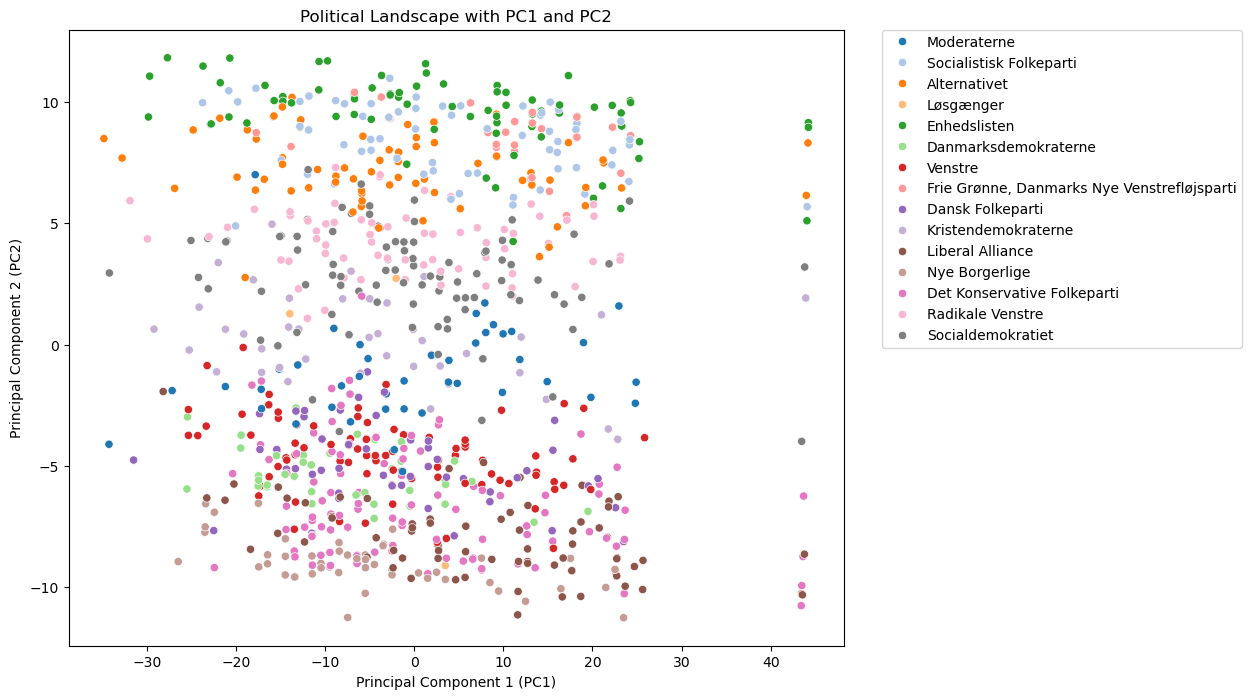

In [32]:
allData_pca_df = pd.DataFrame(data = X_pca, columns = ['PC1', 'PC2','PC3'])
allData_pca_df['parti'] = allData['parti'] 

plt.figure(figsize=(10, 8))
sns.scatterplot(data=allData_pca_df, x="PC1", y="PC2", hue="parti", palette='tab20')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.title('Political Landscape with PC1 and PC2')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.show()

## Crucial questions

In [35]:

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
loadings_df = pd.DataFrame(loadings, columns=['PC1', 'PC2', 'PC3'], index=allData_numeric.columns)
loadings_df


,PC1,PC2,PC3
530,0.138211,1.221847,-0.164986
531,0.143287,1.359140,0.234332
533,-0.200074,-0.877384,0.629848
534,0.001014,-0.286893,0.587111
535,-0.177848,-0.937960,0.085139
537,-0.006109,-1.326881,-0.322798
538,0.119258,0.897507,0.280844
540,-0.103990,-1.191100,-0.504701
541,0.193919,1.216171,-0.206943
543,-0.114975,-1.278396,0.008737


In [37]:
corr_df = allData_numeric.corrwith(allData_pca_df['PC1']).to_frame('PC1').join(allData_numeric.corrwith(allData_pca_df['PC2']).to_frame('PC2'))
corr_df


,PC1,PC2
530,0.097118,0.858562
531,0.088673,0.841108
533,-0.130850,-0.573818
534,0.000731,-0.206905
535,-0.131428,-0.693144
537,-0.003959,-0.859888
538,0.089505,0.673593
540,-0.068363,-0.783029
541,0.123475,0.774378
543,-0.075320,-0.837472


In [39]:
for i in range(2):
    print(f"\nTop Loadings for PC{i + 1}:\n")
    top_positive = loadings_df.nlargest(5, f'PC{i + 1}')
    top_negative = loadings_df.nsmallest(5, f'PC{i + 1}')

    print(f"Top Positive Loadings:\n{top_positive}\n")
    print(f"Top Negative Loadings:\n{top_negative}\n")



Top Loadings for PC1:

Top Positive Loadings:
          PC1       PC2       PC3
544  0.278523  1.213334 -0.148921
561  0.243127  0.804446 -0.241510
541  0.193919  1.216171 -0.206943
6a   0.166163  1.211188 -0.758587
531  0.143287  1.359140  0.234332

Top Negative Loadings:
             PC1       PC2       PC3
alder -14.383996  0.240769 -0.073246
553    -0.227706 -0.093142  0.796800
533    -0.200074 -0.877384  0.629848
535    -0.177848 -0.937960  0.085139
555    -0.164639 -1.249677  0.797842


Top Loadings for PC2:

Top Positive Loadings:
          PC1       PC2       PC3
550  0.074610  1.361892 -0.026200
531  0.143287  1.359140  0.234332
3b   0.080479  1.354063 -0.452473
530  0.138211  1.221847 -0.164986
541  0.193919  1.216171 -0.206943

Top Negative Loadings:
          PC1       PC2       PC3
537 -0.006109 -1.326881 -0.322798
543 -0.114975 -1.278396  0.008737
555 -0.164639 -1.249677  0.797842
6b  -0.157025 -1.191202  0.775778
540 -0.103990 -1.191100 -0.504701



Top Positive Loadings: These are the questions that contribute the most positively to the position along the principal component. A higher positive loading indicates a stronger positive influence on the axis.

Top Negative Loadings: These are the questions that contribute the most negatively to the position along the principal component. A higher negative loading indicates a stronger negative influence on the axis.

## Average Positions Of Parties

In [57]:
allData.head()


,530,531,533,534,535,537,538,540,541,543,...,9a,9b,10a,10b,11a,11b,12a,12b,storkreds,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,2,0,1,-2,-2,1,1,1,Københavns Storkreds,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,-2,0,-1,2,1,-2,0,0,Fyns Storkreds,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,-1,-2,0,2,0,-1,1,-2,Bornholms Storkreds,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,-2,2,2,2,2,-1,2,0,Nordjyllands Storkreds,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,-2,0,-1,0,-2,0,2,-2,Københavns Storkreds,58


In [59]:
grouped_data = allData.drop(['navn', 'storkreds'], axis=1)
grouped_data.head()


,530,531,533,534,535,537,538,540,541,543,...,8b,9a,9b,10a,10b,11a,11b,12a,12b,alder
0,-1,-2,1,-2,2,1,-2,1,1,2,...,0,2,0,1,-2,-2,1,1,1,78
1,2,2,-1,-2,-1,-2,1,-2,2,-2,...,0,-2,0,-1,2,1,-2,0,0,64
2,2,1,-2,-2,1,-2,1,-1,1,-1,...,1,-1,-2,0,2,0,-1,1,-2,37
3,2,1,-2,-1,1,1,1,1,1,-2,...,2,-2,2,2,2,2,-1,2,0,28
4,1,1,-2,2,-2,1,-2,1,2,-2,...,0,-2,0,-1,0,-2,0,2,-2,58


In [61]:
mean_data = grouped_data.groupby('parti').mean().reset_index()
mean_data.head()


,parti,530,531,533,534,535,537,538,540,541,...,8b,9a,9b,10a,10b,11a,11b,12a,12b,alder
0,Alternativet,1.880597,1.134328,-1.895522,-1.820896,-0.776119,-1.641791,-0.716418,0.283582,1.149254,...,1.134328,-1.477612,0.164179,-0.149254,1.029851,0.164179,0.492537,0.492537,-0.671642,46.000000
1,Danmarksdemokraterne,-0.837838,-1.378378,1.513514,-0.972973,1.756757,0.189189,-1.864865,1.054054,-1.918919,...,0.729730,0.567568,-0.702703,0.918919,1.918919,-1.972973,1.891892,0.486486,0.297297,51.216216
2,Dansk Folkeparti,-0.571429,-1.081633,1.551020,1.653061,1.551020,0.000000,-1.551020,0.734694,-1.448980,...,0.489796,0.816327,-0.306122,0.918367,1.448980,-1.693878,1.795918,0.816327,-0.693878,45.530612
3,Det Konservative Folkeparti,-0.836735,-1.877551,0.948980,-1.714286,1.816327,1.408163,-1.979592,1.663265,-1.255102,...,0.275510,0.500000,-0.295918,1.469388,-1.612245,-1.806122,1.806122,0.765306,-0.295918,42.897959
4,Enhedslisten,1.959459,1.864865,-1.918919,0.405405,-1.662162,-1.878378,0.418919,-1.797297,1.635135,...,0.445946,-1.824324,0.283784,-1.040541,1.905405,0.702703,-1.162162,-0.554054,0.108108,40.513514


In [63]:
selected_questions = ['544', '561', '541', '553', '533']

mean_data = pd.melt(mean_data, id_vars=["parti"], value_vars=selected_questions)
mean_data.head()


,parti,variable,value
0,Alternativet,544,1.328358
1,Danmarksdemokraterne,544,-1.783784
2,Dansk Folkeparti,544,-1.755102
3,Det Konservative Folkeparti,544,-1.612245
4,Enhedslisten,544,1.567568


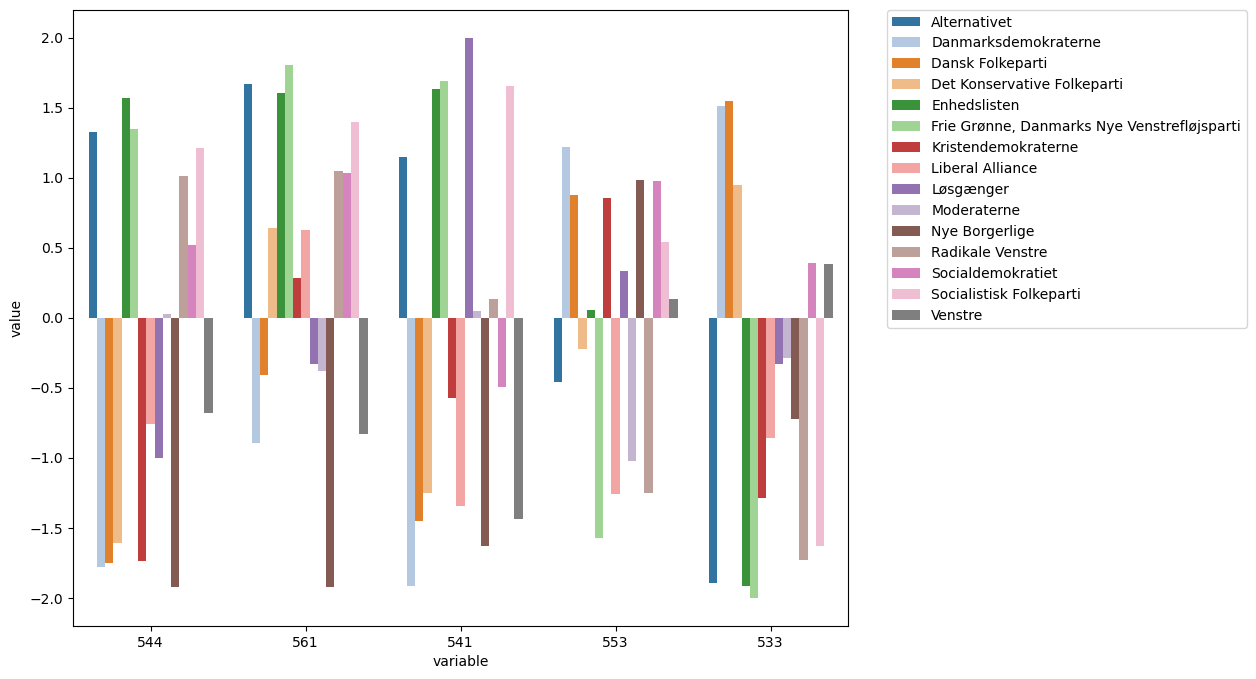

In [65]:
plt.figure(figsize=(10, 8))
sns.barplot(data=mean_data, x="variable", y="value", hue="parti", palette='tab20')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()


## Clustering Analysis

### PCA For Clustering

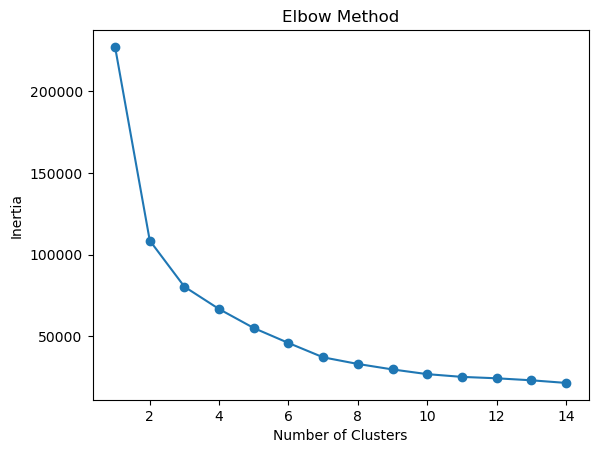

In [72]:
inertia = []

for i in range(1, 15):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()


## K-means clustering

In [75]:
print(X_pca.shape)


(867, 3)


Counter({1: 520, 0: 347})


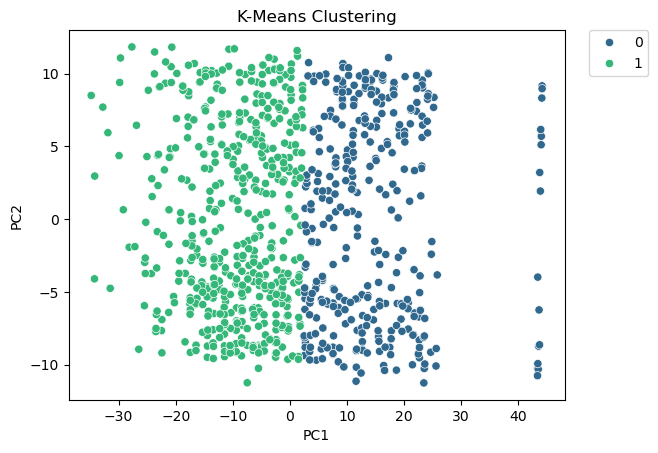

In [79]:
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=0)
X_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2','PC3'])

kmeans_cluster = kmeans.fit_predict(X_pca)
X_pca['Cluster'] = kmeans_cluster
print(collections.Counter(kmeans_cluster))

sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=X_pca, palette='viridis', legend='full')

plt.title('K-Means Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()


Counter({3: 105, 12: 88, 10: 85, 0: 83, 8: 75, 6: 63, 4: 61, 5: 59, 9: 55, 2: 53, 7: 51, 13: 45, 1: 28, 11: 16})


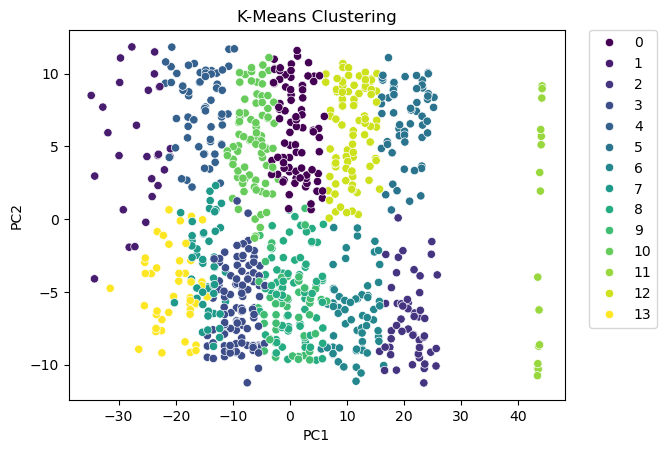

In [81]:
kmeans = KMeans(n_clusters=14, init='k-means++', max_iter=300, n_init=10, random_state=0)

kmeans_cluster = kmeans.fit_predict(X_pca)

print(collections.Counter(kmeans_cluster))

sns.scatterplot(x='PC1', y='PC2', hue=kmeans_cluster, data=X_pca, palette='viridis', legend='full')
plt.title('K-Means Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()

## DBSCAN Clustering

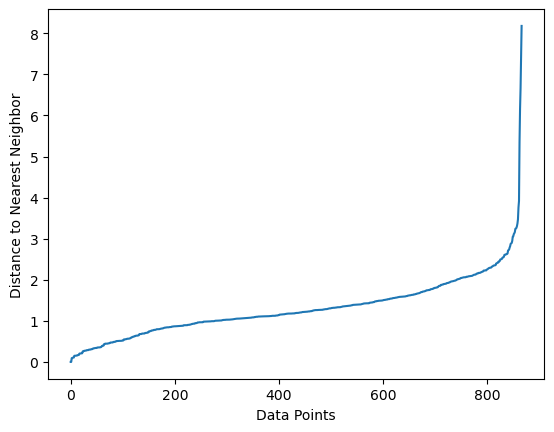

In [84]:
neigh = NearestNeighbors(n_neighbors=2)
distances, indices = neigh.fit(X_pca).kneighbors(X_pca)

distances = np.sort(distances, axis=0)
distances = distances[:,1]

plt.plot(distances)
plt.xlabel('Data Points')
plt.ylabel('Distance to Nearest Neighbor')
plt.show()



In [86]:
dbscan = DBSCAN(eps=3, min_samples=5)
dbscan_clusters = dbscan.fit_predict(X_pca)

print(collections.Counter(dbscan_clusters))


Counter({0: 750, -1: 98, 2: 13, 1: 6})


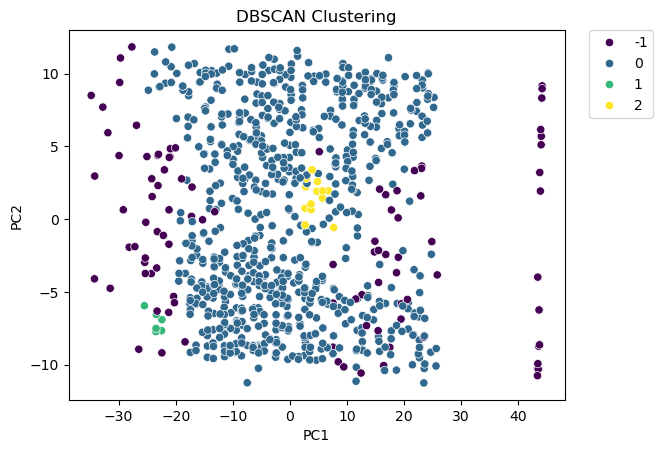

In [88]:
sns.scatterplot(x='PC1', y='PC2', hue=dbscan_clusters, data=X_pca, palette='viridis', legend='full')
plt.title('DBSCAN Clustering')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

plt.show()


## Hierarchical Clustering

In [93]:
from scipy.cluster.hierarchy import linkage, dendrogram
 
X = allData.drop(columns=["storkreds", "alder", "navn", "parti"])
dendogramX = X.T
dendogramX


,0,1,2,3,4,5,6,7,8,9,...,857,858,859,860,861,862,863,864,865,866
530,-1,2,2,2,1,2,1,-1,1,1,...,2,2,1,1,1,1,1,1,1,1
531,-2,2,1,1,1,1,2,2,-1,1,...,-2,-1,1,1,1,1,-2,1,-1,1
533,1,-1,-2,-2,-2,-2,-1,-2,-1,-2,...,-2,-1,-1,2,1,1,-2,1,1,-1
534,-2,-2,-2,-1,2,-2,-2,-2,-1,-2,...,-2,-2,-2,-2,-2,-2,-2,-2,-2,-2
535,2,-1,1,1,-2,-1,1,-2,2,1,...,2,-1,2,2,2,2,1,2,1,1
537,1,-2,-2,1,1,-1,1,-2,-1,-2,...,-1,-1,-1,-1,-1,-1,-2,-1,-1,-1
538,-2,1,1,1,-2,-1,-2,-1,-1,-2,...,1,1,1,1,1,1,-1,1,-1,1
540,1,-2,-1,1,1,1,1,-1,1,-1,...,1,1,-1,-1,-1,-2,-2,-1,-1,-1
541,1,2,1,1,2,1,1,1,2,1,...,-1,-1,-1,-1,-1,1,-2,-1,-1,1
543,2,-2,-1,-2,-2,-1,-1,-1,1,-2,...,-1,-1,1,1,1,1,-2,1,1,-1


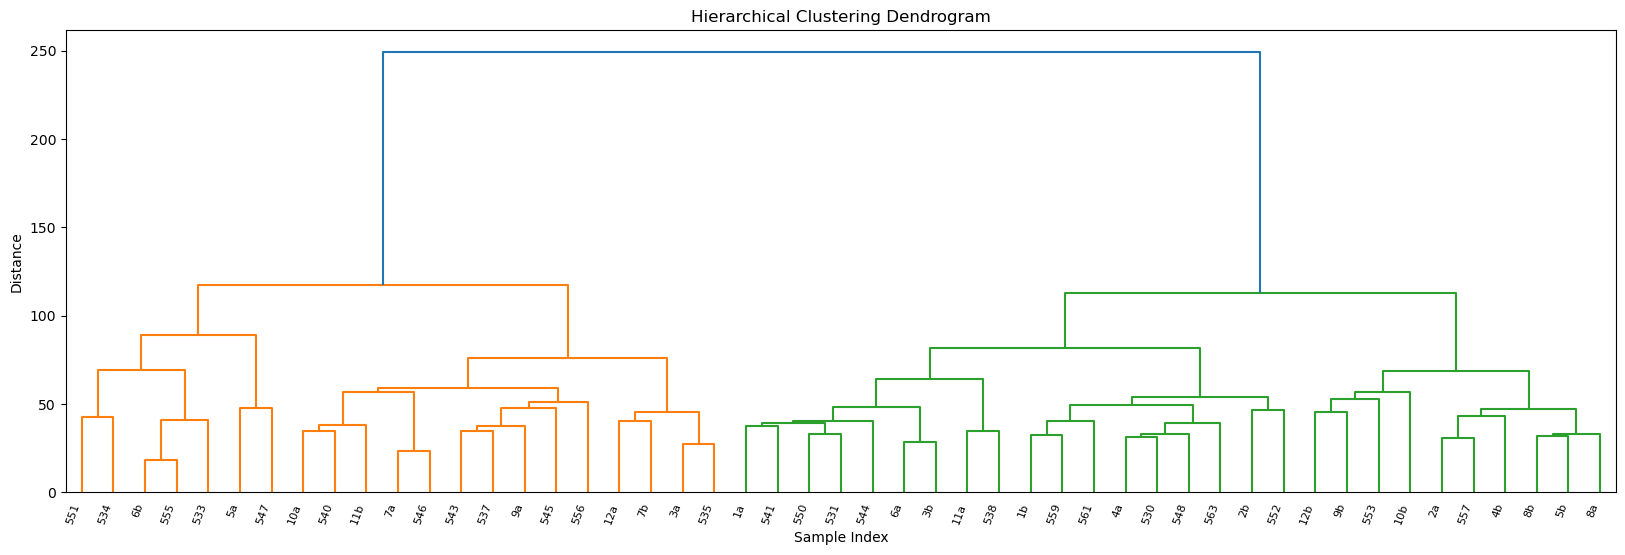

In [97]:
linkage_matrix = linkage(dendogramX, method='ward')

plt.figure(figsize=(20, 6))
dendrogram(linkage_matrix, labels=dendogramX.index, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.xticks(rotation=70, ha='right')

plt.show()

## Overview of the Political Landscape of Elected Candidates

In [100]:
allData["greater_than_40"] = allData["alder"]>40
df = allData.drop(columns=['navn','storkreds', 'alder', 'greater_than_40'])

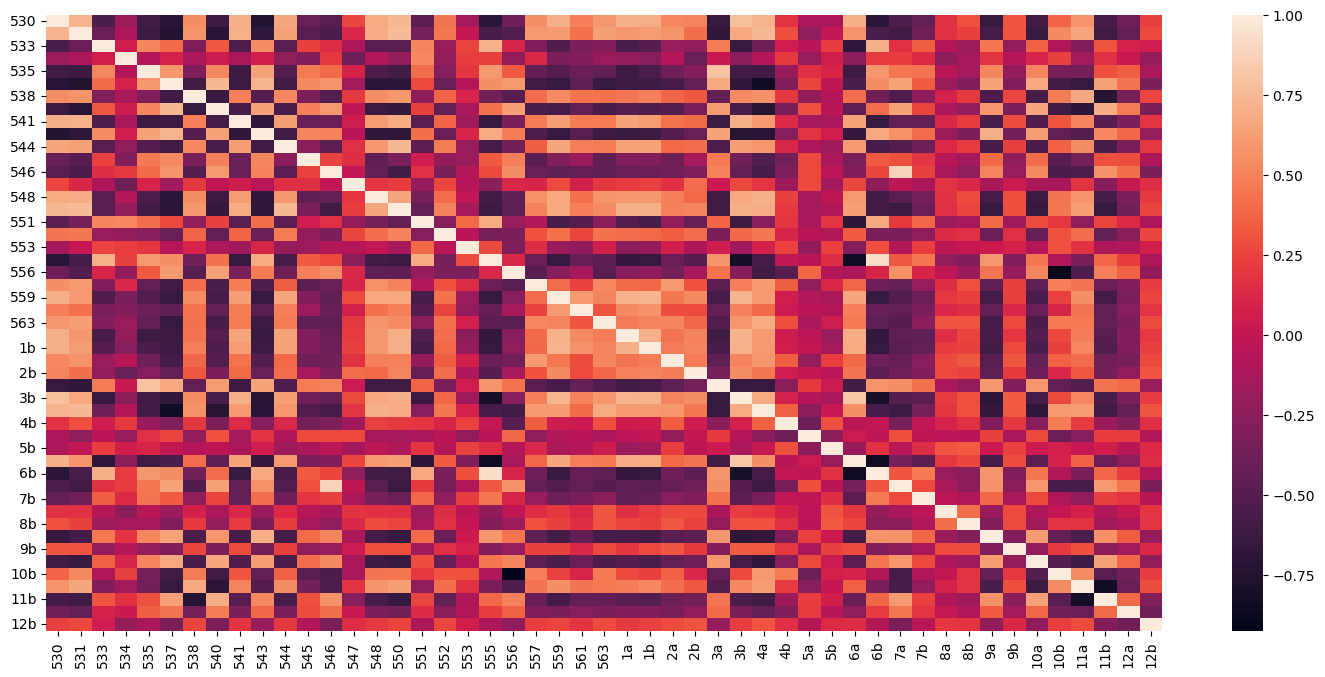

In [102]:
df_no_party = df.drop(columns=["parti"])
plt.figure(figsize=(18,8))
sns.heatmap(df_no_party.corr())
plt.show()

In [104]:
correlation_matrix = df_no_party.corr()

threshold = 0.8

correlated_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            correlated_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j]))


print("Questions with correlation greater than ", threshold, ":")
print(*correlated_pairs, sep="\n")


Questions with correlation greater than  0.8 :
('537', '4a')
('546', '7a')
('555', '3b')
('555', '6a')
('555', '6b')
('556', '10b')
('3b', '6a')
('3b', '6b')
('6a', '6b')
('11a', '11b')


In [106]:
df_transposed = df.pivot_table(columns='parti', values=df.columns.difference(['parti']))
df_transposed.head()

parti,Alternativet,Danmarksdemokraterne,Dansk Folkeparti,Det Konservative Folkeparti,Enhedslisten,"Frie Grønne, Danmarks Nye Venstrefløjsparti",Kristendemokraterne,Liberal Alliance,Løsgænger,Moderaterne,Nye Borgerlige,Radikale Venstre,Socialdemokratiet,Socialistisk Folkeparti,Venstre
10a,-0.149254,0.918919,0.918367,1.469388,-1.040541,-0.461538,0.595238,1.671429,0.333333,1.071429,1.843137,0.283582,-0.471264,-0.728571,1.095238
10b,1.029851,1.918919,1.448980,-1.612245,1.905405,1.615385,-1.333333,-1.928571,0.666667,-1.142857,0.666667,-0.223881,1.896552,1.814286,0.095238
11a,0.164179,-1.972973,-1.693878,-1.806122,0.702703,-1.115385,-0.976190,-1.957143,-0.666667,-1.309524,-1.960784,-0.940299,1.597701,1.142857,-1.797619
11b,0.492537,1.891892,1.795918,1.806122,-1.162162,1.346154,1.023810,1.871429,0.000000,1.380952,2.000000,-0.567164,-1.827586,-1.371429,1.821429
12a,0.492537,0.486486,0.816327,0.765306,-0.554054,0.000000,1.023810,1.571429,1.666667,0.928571,1.588235,0.731343,0.275862,0.171429,0.976190


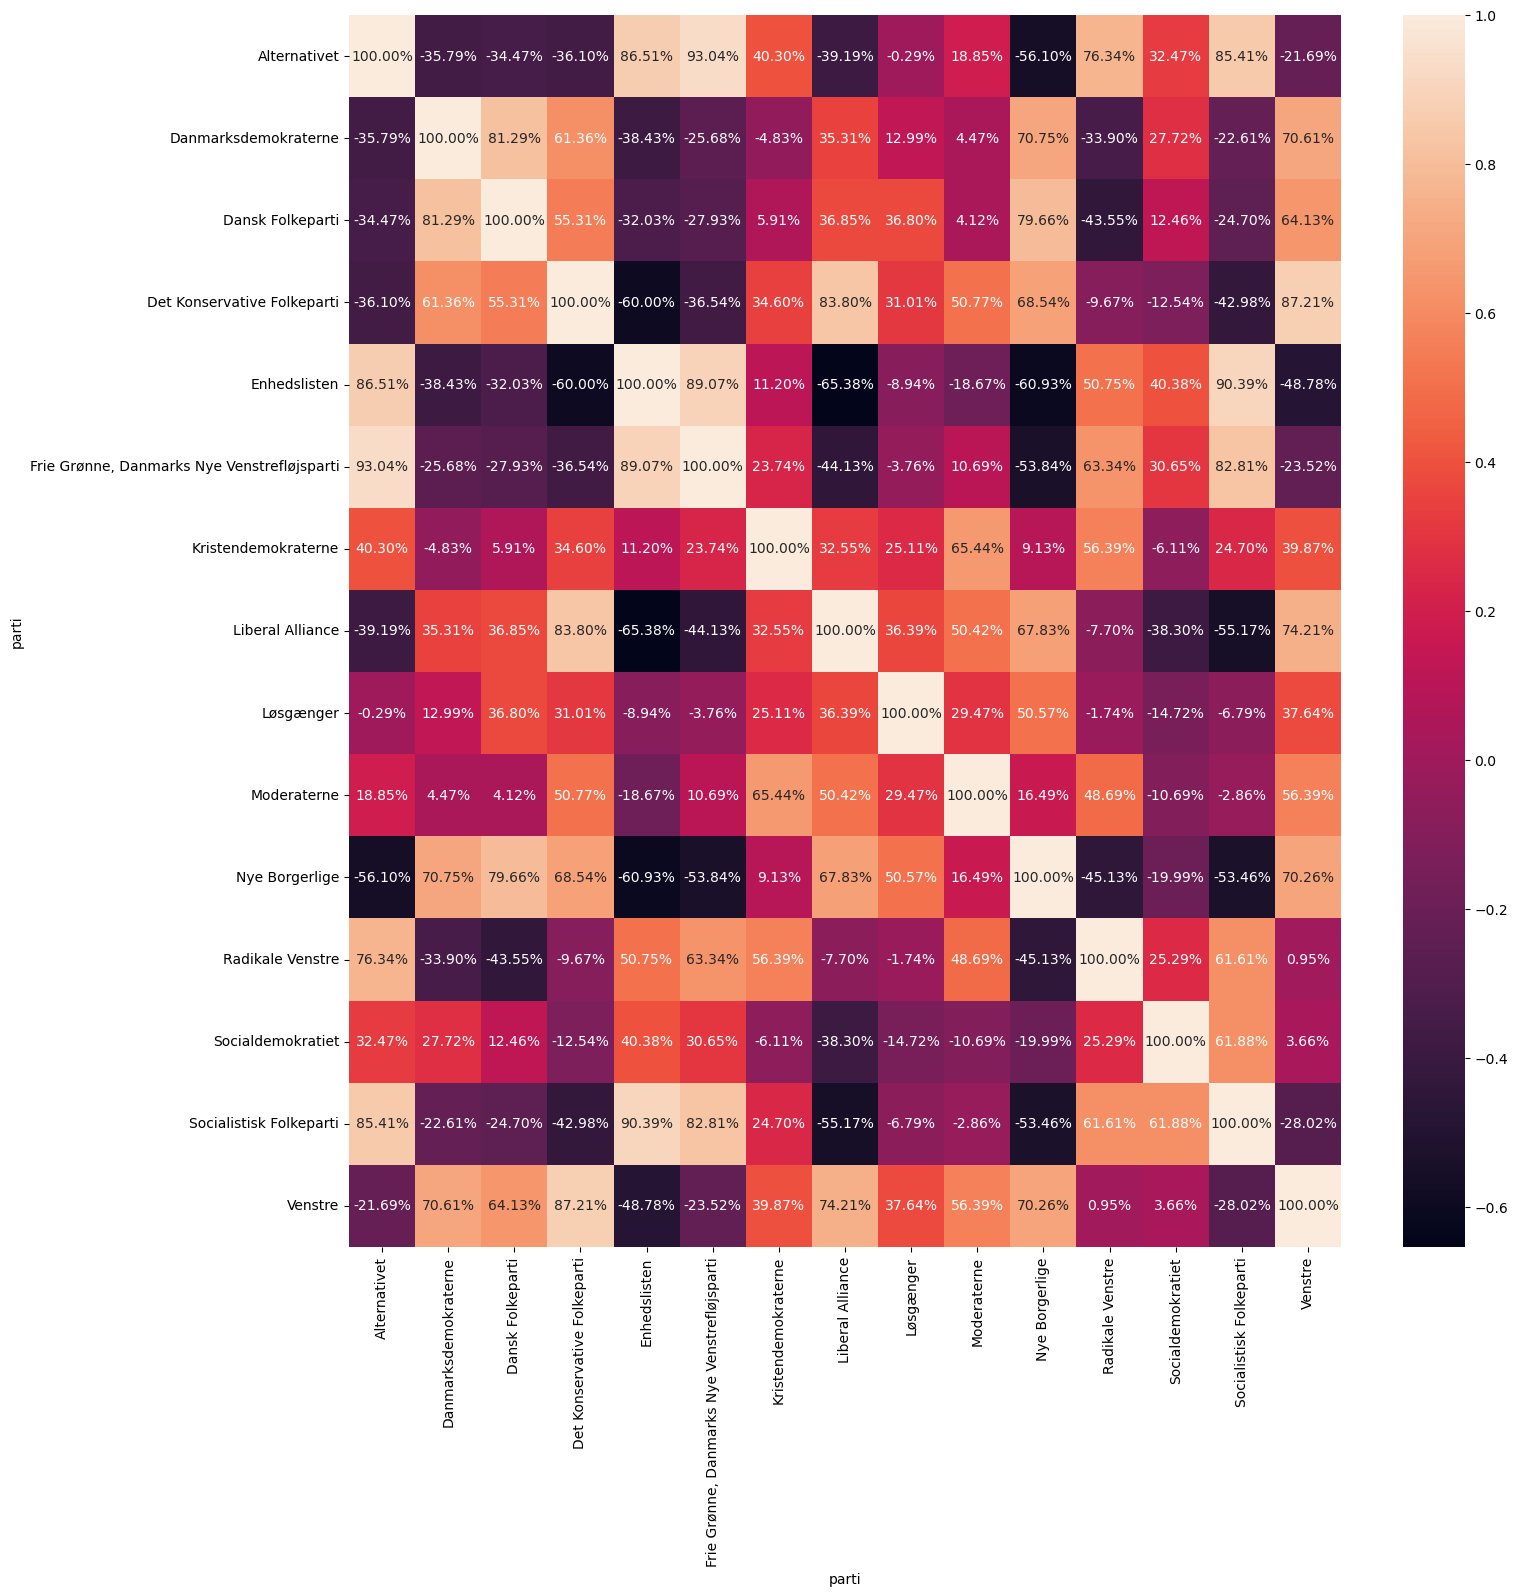

In [108]:
plt.figure(figsize=(16, 16))
sns.heatmap(df_transposed.corr(), annot=True, fmt=".2%")
plt.show()